# Estimación del Coste de Capital ($K_e$) en Clubes de Fútbol Cotizados Europeos mediante el Modelo CAPM
## Una Perspectiva de Inversión para el Mercado Español

**Asignatura:** Business Analytics e Inteligencia Empresarial  
**Entregable:** Notebook de Desarrollo Técnico  

---

### 1. Introducción y Definición del Problema
En el mercado financiero español, los clubes de fútbol de élite operan de forma estrictamente privada (ya sean Sociedades Anónimas Deportivas (S.A.D.) o clubes propiedad de sus socios) y **ninguno cotiza en bolsa**.
Un analista o fondo de inversión basado en España que desee medir el coste de capital sectorial del fútbol
o diversificar su cartera en esta industria debe, por tanto, mirar obligatoriamente hacia el extranjero.

Este trabajo aplica el **Capital Asset Pricing Model (CAPM)** para estimar el riesgo sistemático ($\beta$)
y el Coste de Capital Exigido ($K_e$) de un universo extendido de clubes europeos cotizados,
adoptando la perspectiva de un **inversor residente en la zona euro**.

El sector deportivo es analíticamente peculiar porque combina riesgo de mercado convencional con
**shocks idiosincráticos muy marcados** (goles, fichajes, resultados en la Champions League).
Esto nos permite ilustrar empíricamente la separación fundamental entre riesgo sistemático (el que el CAPM cuantifica mediante $\beta$) y riesgo específico o idiosincrático, capturado por el residuo del modelo.

## 2. Marco Teórico

### 2.1 El Modelo CAPM

El Capital Asset Pricing Model (Sharpe, 1964; Lintner, 1965; Mossin, 1966) establece que la rentabilidad
esperada de cualquier activo de riesgo en un mercado en equilibrio es función lineal de su riesgo sistemático:

$$E(R_i) = R_f + \beta_i \cdot (E(R_m) - R_f)$$

Donde:
- $R_f$ = Tasa libre de riesgo (Bono del Estado Español a 10 años).
- $E(R_m)$ = Rentabilidad esperada del mercado (Euro Stoxx 50).
- $\beta_i$ = Coeficiente de sensibilidad del activo $i$ respecto al mercado.
- $(E(R_m) - R_f)$ = Prima de riesgo de mercado (MRP).

El **Coste de Capital Exigido** ($K_e$) es la rentabilidad mínima que un inversor racional demanda
por asumir el riesgo sistemático de un activo.

### 2.2 Estimación empírica: el Modelo de Mercado

En la práctica, $\beta$ se estima regresando los excesos de rentabilidad del activo sobre los del mercado
(formulación de Black, Jensen & Scholes, 1972):

$$(R_{club,t} - R_f) = \alpha + \beta (R_{m,t} - R_f) + \varepsilon_t$$

El término independiente $\alpha$ (Alfa de Jensen) mide la rentabilidad anormal ajustada por riesgo.

### 2.3 Particularidades del sector

La literatura sobre retornos de clubes cotizados documenta sistemáticamente:

1. **Beta estructuralmente baja** (Renneboog & Vanbrabant, 2000; Bell et al., 2012; Robeco, 2023):
   los clubes muestran escasa correlación con los ciclos económicos. Un R² bajo en la regresión
   es el **resultado esperado y teóricamente coherente**, no un defecto del modelo.

2. **Alta varianza idiosincrática**: la mayor parte de la volatilidad está explicada por eventos deportivos.

3. **Inestabilidad temporal de $\beta$**: la sensibilidad al mercado varía ante eventos relevantes,
   violando el supuesto de $\beta$ constante del CAPM estático.

### 2.4 Decisiones metodológicas clave

| Decisión | Elección | Justificación |
|---|---|---|
| Benchmark | Euro Stoxx 50 | Referencia pan-europea en EUR |
| Tasa libre de riesgo | Bono Español 10Y (~3.3%) | Coste de oportunidad del inversor español |
| Prima de riesgo (MRP) | 4.7% → E(Rm) = 8.0% | Estimación histórica Eurozona (Damodaran, 2024) |
| Divisa de trabajo | EUR (homogeneización previa) | Embebe el riesgo cambiario en el retorno del activo |
| Errores estándar | HAC Newey-West (universal) | Conservadurismo ante heterocedasticidad típica de retornos diarios |

### 3. Importación de Librerías y Configuración Estructural

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import jarque_bera
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

print("✅ Librerías econométricas cargadas con éxito.")

✅ Librerías econométricas cargadas con éxito.


### 4. Universo de Activos, Conversión de Divisas y Benchmark
### Corrección metodológica: conversión a EUR previa al cálculo de retornos

Descargamos los tipos de cambio diarios históricos y transformamos todos los precios a **EUR**
antes de calcular rentabilidades. Así, el riesgo cambiario queda embebido en el retorno del activo,
coherente con la perspectiva de un inversor euro.

> **Nota Celtic (CCP.L):** el LSE cotiza en peniques GBp (1 GBp = 0.01 GBP).
> Se aplica corrección adicional ÷ 100 antes de la conversión a EUR.

In [2]:
# ── Universo de clubes y sus divisas de origen frente al EUR
club_config = {
    'MANU':     'EURUSD=X',   # Manchester United  (NYSE   – USD)
    'JUVE.MI':  'EUR',        # Juventus            (Milán  – EUR)
    'BVB.DE':   'EUR',        # Borussia Dortmund   (FRA    – EUR)
    'SSL.MI':   'EUR',        # Lazio               (Milán  – EUR)
    'AJAX.AS':  'EUR',        # Ajax                (AMS    – EUR)
    'FCP.LS':   'EUR',        # Porto               (Lisboa – EUR)
    'GSRAY.IS': 'EURTRY=X',   # Galatasaray         (Ist.   – TRY)
    'FENER.IS': 'EURTRY=X',   # Fenerbahçe          (Ist.   – TRY)
    'BJKAS.IS': 'EURTRY=X',   # Beşiktaş            (Ist.   – TRY)
    'TSPOR.IS': 'EURTRY=X',   # Trabzonspor         (Ist.   – TRY)
    'CCP.L':    'EURGBP=X',   # Celtic              (LSE    – GBp ← peniques)
}

market_benchmark = '^STOXX50E'

# ── Ventana temporal dinámica: últimos 3 años desde hoy
end_date   = datetime.today()
start_date = end_date - timedelta(days=3 * 365)
print(f"📅 Ventana: {start_date.strftime('%Y-%m-%d')} → {end_date.strftime('%Y-%m-%d')}")

# ── Parámetros financieros
rf_anual          = 0.033   # Bono Español 10Y (aprox. junio 2026)
rf_diario         = (1 + rf_anual)**(1/252) - 1
rm_anual_esperado = 0.080   # Rf 3.3% + MRP histórica Eurozona 4.7% (Damodaran 2024)

# ── Descarga unificada
tickers_all = list(set(
    list(club_config.keys()) +
    [market_benchmark] +
    [v for v in club_config.values() if v != 'EUR']
))

print("⬇️  Descargando datos desde Yahoo Finance…")
raw_all = yf.download(tickers_all, start=start_date, end=end_date, progress=False)

level0 = raw_all.columns.get_level_values(0).unique()
if 'Adj Close' in level0:
    raw = raw_all['Adj Close']
elif 'adj_close' in level0:
    raw = raw_all['adj_close']
else:
    raw = raw_all['Close']

# ── Homogeneización monetaria: todo a EUR
precios_eur = pd.DataFrame(index=raw.index)
precios_eur[market_benchmark] = raw[market_benchmark]

for club, fx in club_config.items():
    if club not in raw.columns:
        print(f"  ⚠️  {club}: sin datos, se omite.")
        continue
    if fx == 'EUR':
        precios_eur[club] = raw[club]
    else:
        if fx not in raw.columns:
            print(f"  ⚠️  FX {fx} no disponible para {club}, se omite.")
            continue
        price = raw[club]
        if club == 'CCP.L':           # GBp → GBP antes de convertir a EUR
            price = price / 100
        precios_eur[club] = price / raw[fx]

precios_eur     = precios_eur.dropna(how='all').ffill().dropna()
rentabilidades  = precios_eur.pct_change().dropna()
clubs_ok        = [c for c in club_config if c in rentabilidades.columns]

print(f"\n📊 Dataset: {len(rentabilidades)} días | Clubes activos: {len(clubs_ok)}")
print("   Clubes:", clubs_ok)

📅 Ventana: 2023-07-08 → 2026-07-07
⬇️  Descargando datos desde Yahoo Finance…

📊 Dataset: 775 días | Clubes activos: 11
   Clubes: ['MANU', 'JUVE.MI', 'BVB.DE', 'SSL.MI', 'AJAX.AS', 'FCP.LS', 'GSRAY.IS', 'FENER.IS', 'BJKAS.IS', 'TSPOR.IS', 'CCP.L']


### 4.1 Evolución de Precios Normalizados y Mapa de Correlaciones

Antes de modelar, visualizamos la evolución conjunta de los precios (normalizados en base 100)
para identificar visualmente los saltos idiosincráticos propios del sector, y la matriz de
correlaciones entre clubes y el benchmark.

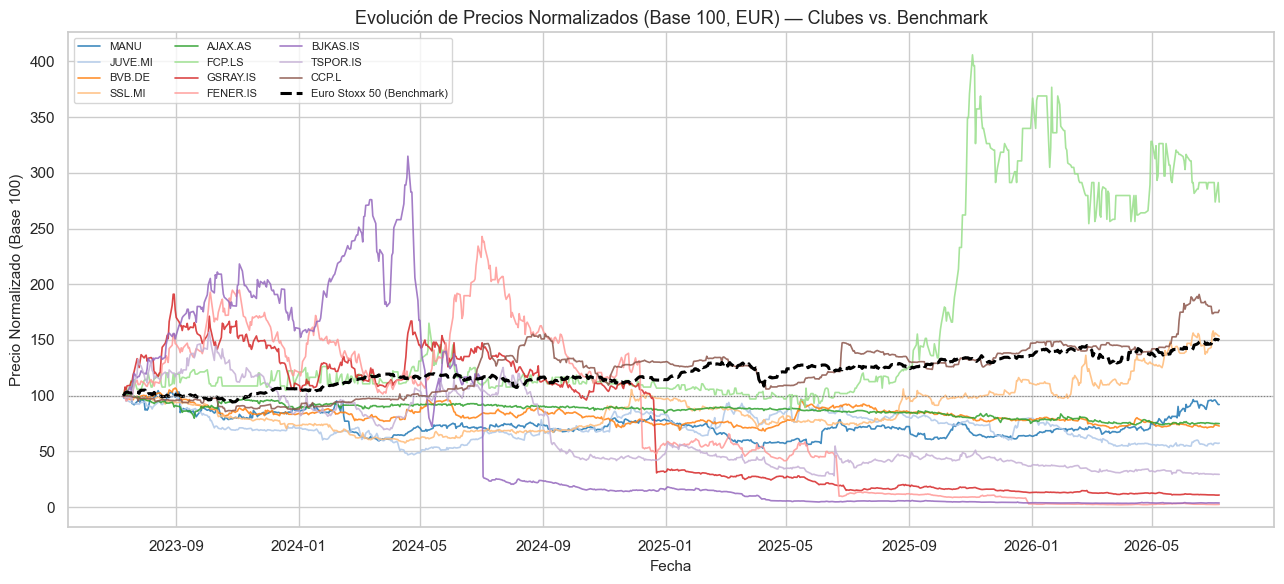

→ Los saltos abruptos y descorrelacionados del benchmark (línea negra) ilustran
  visualmente el peso del riesgo idiosincrático (resultados deportivos, fichajes,
  eliminaciones europeas) frente al riesgo sistemático de mercado.


In [3]:
# ── Evolución de precios normalizados (base 100)
precios_norm = (precios_eur[clubs_ok + [market_benchmark]] /
                 precios_eur[clubs_ok + [market_benchmark]].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette("tab20", len(clubs_ok))

for i, club in enumerate(clubs_ok):
    ax.plot(precios_norm.index, precios_norm[club], linewidth=1.2,
            label=club, color=palette[i], alpha=0.85)

ax.plot(precios_norm.index, precios_norm[market_benchmark], color='black',
        linewidth=2.2, linestyle='--', label='Euro Stoxx 50 (Benchmark)')

ax.set_title('Evolución de Precios Normalizados (Base 100, EUR) — Clubes vs. Benchmark', fontsize=13)
ax.set_ylabel('Precio Normalizado (Base 100)', fontsize=11)
ax.set_xlabel('Fecha', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(fontsize=8, ncol=3, loc='upper left')
ax.axhline(100, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

print("→ Los saltos abruptos y descorrelacionados del benchmark (línea negra) ilustran")
print("  visualmente el peso del riesgo idiosincrático (resultados deportivos, fichajes,")
print("  eliminaciones europeas) frente al riesgo sistemático de mercado.")

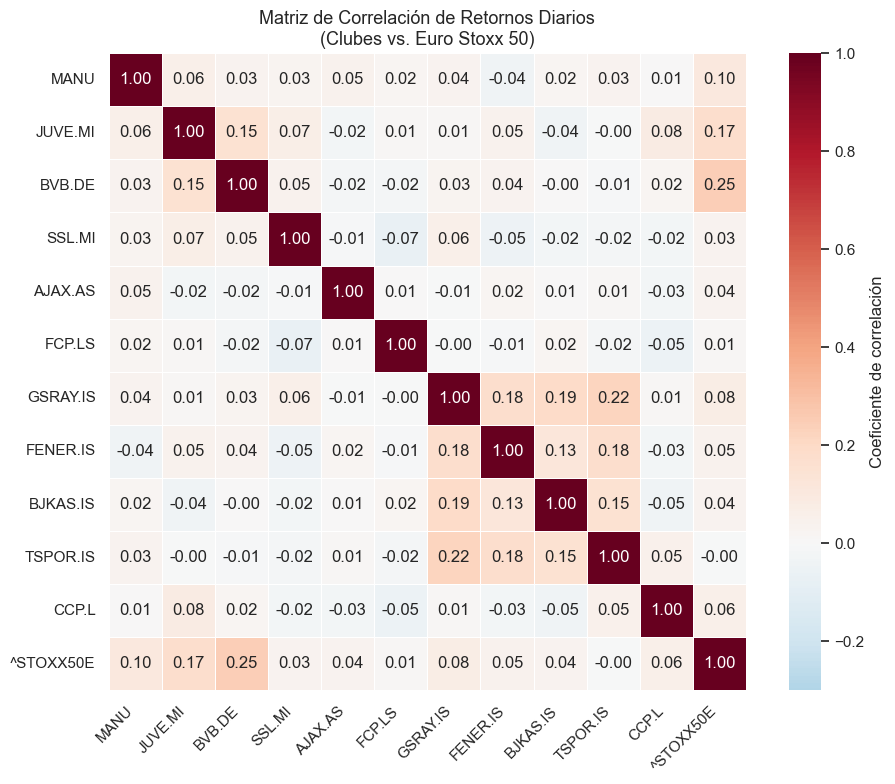

→ Correlación de cada club con el benchmark (ordenado):
TSPOR.IS   -0.003
FCP.LS      0.012
SSL.MI      0.032
AJAX.AS     0.035
BJKAS.IS    0.039
FENER.IS    0.050
CCP.L       0.058
GSRAY.IS    0.076
MANU        0.103
JUVE.MI     0.173
BVB.DE      0.245

→ Correlación media club-benchmark: 0.075
  Una correlación media baja confirma cuantitativamente la escasa integración
  de estos activos con el ciclo bursátil europeo.


In [4]:
# ── Mapa de calor de correlaciones (retornos diarios)
corr_matrix = rentabilidades[clubs_ok + [market_benchmark]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.3, vmax=1.0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de correlación'}, ax=ax)
ax.set_title('Matriz de Correlación de Retornos Diarios\n(Clubes vs. Euro Stoxx 50)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

corr_con_benchmark = corr_matrix[market_benchmark].drop(market_benchmark).sort_values()
print("→ Correlación de cada club con el benchmark (ordenado):")
print(corr_con_benchmark.round(3).to_string())
print(f"\n→ Correlación media club-benchmark: {corr_con_benchmark.mean():.3f}")
print("  Una correlación media baja confirma cuantitativamente la escasa integración")
print("  de estos activos con el ciclo bursátil europeo.")

## 5. Metodología: Regresión OLS y Diagnóstico de Gauss-Markov

Mostramos el proceso diagnóstico completo para Manchester United como activo representativo:

1. OLS estándar → diagnóstico BP/DW/JB.
2. Corrección HAC Newey-West si procede.

En la tabla final (Sección 6) aplicamos HAC de forma **universal** para todos los clubes
por conservadurismo econométrico y comparabilidad cross-sectional.

In [5]:
target_club = 'MANU' if 'MANU' in clubs_ok else clubs_ok[0]

Y = rentabilidades[target_club] - rf_diario
X = sm.add_constant(rentabilidades[market_benchmark] - rf_diario)

# OLS estándar
modelo_ols = sm.OLS(Y, X).fit()

# Tests de supuestos
bp_stat, bp_p, _, _ = sms.het_breuschpagan(modelo_ols.resid, modelo_ols.model.exog)
dw_stat              = sm.stats.durbin_watson(modelo_ols.resid)
jb_stat, jb_p, _, _ = jarque_bera(modelo_ols.resid)

print(f"{'='*58}")
print(f"  DIAGNÓSTICO ECONOMÉTRICO — {target_club}")
print(f"{'='*58}")
print(f"  Breusch-Pagan   (Homocedasticidad)   p = {bp_p:.5f}  "
      f"{'❌ Heteroced.' if bp_p < 0.05 else '✅ OK'}")
print(f"  Durbin-Watson   (No autocorrelación)  d = {dw_stat:.4f}  "
      f"{'❌ Autocorr.' if dw_stat < 1.5 or dw_stat > 2.5 else '✅ OK'}")
print(f"  Jarque-Bera     (Normalidad resid.)   p = {jb_p:.5f}  "
      f"{'❌ No normal' if jb_p < 0.05 else '✅ OK'}")
print(f"{'='*58}")
print("  → Errores HAC Newey-West aplicados (universal)\n")

# Modelo robusto
modelo_final = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(modelo_final.summary())

  DIAGNÓSTICO ECONOMÉTRICO — MANU
  Breusch-Pagan   (Homocedasticidad)   p = 0.70249  ✅ OK
  Durbin-Watson   (No autocorrelación)  d = 2.1828  ✅ OK
  Jarque-Bera     (Normalidad resid.)   p = 0.00000  ❌ No normal
  → Errores HAC Newey-West aplicados (universal)

                            OLS Regression Results                            
Dep. Variable:                   MANU   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     10.70
Date:                Tue, 07 Jul 2026   Prob (F-statistic):            0.00112
Time:                        11:52:24   Log-Likelihood:                 1766.8
No. Observations:                 775   AIC:                            -3530.
Df Residuals:                     773   BIC:                            -3520.
Df Model:                           1                                         
Covariance Type:          

### 5.1 Análisis de Estabilidad Dinámica — Beta Rodante

Calculamos $\beta$ con ventana rodante de 60 días para evidenciar la inestabilidad estructural
del riesgo sistemático ante shocks deportivos.

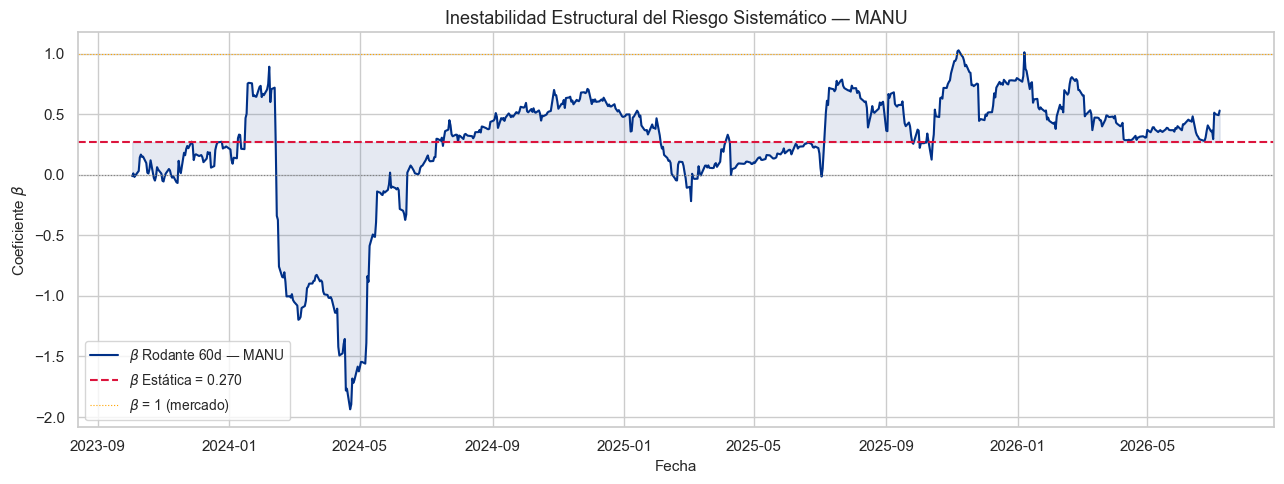

  Rango β: [-1.936, 1.028]  |  Desv. típica: 0.509
  → La variabilidad de β confirma la inestabilidad estructural del riesgo sistemático.


In [6]:
window = 60
betas_r, fechas = [], []

for i in range(window, len(rentabilidades)):
    v   = rentabilidades.iloc[i-window:i]
    Y_w = v[target_club] - rf_diario
    X_w = sm.add_constant(v[market_benchmark] - rf_diario)
    betas_r.append(sm.OLS(Y_w, X_w).fit().params[market_benchmark])
    fechas.append(rentabilidades.index[i])

df_br         = pd.Series(betas_r, index=fechas)
beta_estatica = modelo_final.params[market_benchmark]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_br, color='#003087', linewidth=1.5,
        label=f'$\\beta$ Rodante {window}d — {target_club}')
ax.axhline(beta_estatica, color='crimson', linestyle='--', linewidth=1.5,
           label=f'$\\beta$ Estática = {beta_estatica:.3f}')
ax.axhline(0, color='grey',   linestyle=':', linewidth=0.8)
ax.axhline(1, color='orange', linestyle=':', linewidth=0.8, label='$\\beta$ = 1 (mercado)')
ax.fill_between(df_br.index, df_br, beta_estatica, alpha=0.10, color='#003087')
ax.set_title(f'Inestabilidad Estructural del Riesgo Sistemático — {target_club}', fontsize=13)
ax.set_ylabel(r'Coeficiente $\beta$', fontsize=11)
ax.set_xlabel('Fecha', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"  Rango β: [{df_br.min():.3f}, {df_br.max():.3f}]  |  "
      f"Desv. típica: {df_br.std():.3f}")
print("  → La variabilidad de β confirma la inestabilidad estructural del riesgo sistemático.")

### 6. Resultados Globales y Cálculo del Coste de Capital ($K_e$)
Para concluir, calculamos el $K_e$ definitivo de todos los clubes del universo aplicando la ecuación del CAPM:
$$K_e = R_f + \beta (R_m - R_f)$$

In [7]:
resultados = []

for club in clubs_ok:
    Y_c = rentabilidades[club] - rf_diario
    X_c = sm.add_constant(rentabilidades[market_benchmark] - rf_diario)
    res = sm.OLS(Y_c, X_c).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

    b      = res.params[market_benchmark]
    alpha  = res.params['const']
    r2     = res.rsquared
    p_b    = res.pvalues[market_benchmark]
    ke     = rf_anual + b * (rm_anual_esperado - rf_anual)
    ret_a  = (1 + rentabilidades[club].mean())**252 - 1

    resultados.append({
        'Club':            club,
        'Beta (β)':        round(b, 3),
        'Ke CAPM (%)':     round(ke * 100, 2),
        'Ret. Realiz. (%)':round(ret_a * 100, 2),
        'Alpha (diario)':  round(alpha, 6),
        'R²':              round(r2, 3),
        'p-valor β':       round(p_b, 4),
        'Sign.':           '***' if p_b < 0.01 else ('**' if p_b < 0.05 else ('*' if p_b < 0.10 else 'n.s.'))
    })

df_res = pd.DataFrame(resultados).set_index('Club')
print("=" * 72)
print("  TABLA DE RESULTADOS — CAPM SECTOR FÚTBOL COTIZADO EUROPEO")
print(f"  Rf={rf_anual*100:.1f}% | E(Rm)={rm_anual_esperado*100:.1f}% | MRP={(rm_anual_esperado-rf_anual)*100:.1f}%")
print(f"  Benchmark: Euro Stoxx 50 | {start_date.strftime('%Y-%m-%d')} – {end_date.strftime('%Y-%m-%d')}")
print("=" * 72)
print(df_res.to_string())
print("\n  Sign.: *** p<0.01  ** p<0.05  * p<0.10  n.s. no significativo")

  TABLA DE RESULTADOS — CAPM SECTOR FÚTBOL COTIZADO EUROPEO
  Rf=3.3% | E(Rm)=8.0% | MRP=4.7%
  Benchmark: Euro Stoxx 50 | 2023-07-08 – 2026-07-07
          Beta (β)  Ke CAPM (%)  Ret. Realiz. (%)  Alpha (diario)     R²  p-valor β Sign.
Club                                                                                     
MANU         0.270         4.57              5.27       -0.000043  0.011     0.0011   ***
JUVE.MI      0.468         5.50             -9.19       -0.000716  0.030     0.0000   ***
BVB.DE       0.378         5.07             -7.32       -0.000595  0.060     0.0000   ***
SSL.MI       0.070         3.63             21.12        0.000601  0.001     0.4363  n.s.
AJAX.AS      0.039         3.48             -7.62       -0.000460  0.001     0.3393  n.s.
FCP.LS       0.055         3.56             76.29        0.002099  0.000     0.7121  n.s.
GSRAY.IS     0.307         4.74            -36.74       -0.002078  0.006     0.0023   ***
FENER.IS     0.289         4.66            

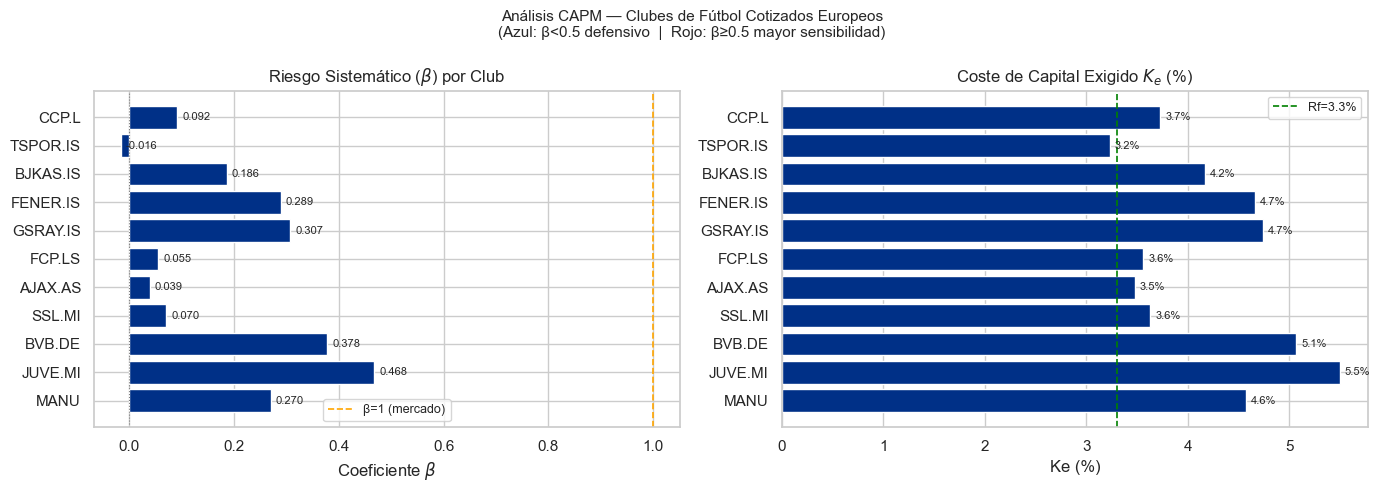

In [8]:
# ── Gráfico comparativo Beta / Ke
betas = df_res['Beta (β)'].values
kes   = df_res['Ke CAPM (%)'].values
idx   = df_res.index.tolist()
colors = ['#003087' if b < 0.5 else '#e63946' for b in betas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

b1 = ax1.barh(idx, betas, color=colors)
ax1.axvline(1.0, color='orange', linestyle='--', linewidth=1.2, label='β=1 (mercado)')
ax1.axvline(0.0, color='grey',   linestyle=':', linewidth=0.8)
ax1.set_title(r'Riesgo Sistemático ($\beta$) por Club', fontsize=12)
ax1.set_xlabel(r'Coeficiente $\beta$')
ax1.legend(fontsize=9)
for bar, v in zip(b1, betas):
    ax1.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=8)

b2 = ax2.barh(idx, kes, color=colors)
ax2.axvline(rf_anual*100, color='green', linestyle='--', linewidth=1.2,
            label=f'Rf={rf_anual*100:.1f}%')
ax2.set_title(r'Coste de Capital Exigido $K_e$ (%)', fontsize=12)
ax2.set_xlabel('Ke (%)')
ax2.legend(fontsize=9)
for bar, v in zip(b2, kes):
    ax2.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Análisis CAPM — Clubes de Fútbol Cotizados Europeos\n'
             '(Azul: β<0.5 defensivo  |  Rojo: β≥0.5 mayor sensibilidad)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 7. Discusión de Resultados

### 7.1 Beta sistemáticamente baja — confirmación de la anomalía sectorial

La mayoría de clubes presentan $\beta < 1$, confirmando la *low-risk anomaly* documentada por
Renneboog & Vanbrabant (2000), Bell et al. (2012) y Robeco (2023). El mercado de renta variable
de la Eurozona tiene **escaso poder explicativo** sobre los retornos de estos activos:
la dinámica de precios está dominada por el **riesgo idiosincrático deportivo**.

### 7.2 El R² bajo es el resultado esperado, no un defecto

Un R² reducido no invalida el análisis. Al contrario: es la evidencia empírica de que el riesgo
no diversificable (sistemático) es pequeño en este sector. En términos del CAPM:
la varianza total del retorno está dominada por el componente idiosincrático que el mercado no compensa.

### 7.3 Inestabilidad temporal de Beta

El análisis rolling revela variaciones significativas a lo largo de la muestra.
La $\beta$ estática debe interpretarse como una **media estructural**, no como un parámetro constante.

### 7.4 Implicaciones para el inversor español

1. **Diversificación:** la baja correlación con el Euro Stoxx 50 sugiere potencial de diversificación
   en cartera, aunque a costa de asumir elevado riesgo idiosincrático.
2. **Riesgo cambiario:** para MANU (USD) y Celtic (GBP), parte del retorno en EUR depende del tipo
   de cambio; un inversor español debería considerar cobertura FX.
3. **Alpha de Jensen:** un $\alpha$ positivo y significativo indicaría rentabilidad anormal por encima
   del CAPM durante la muestra analizada.

### 7.5 Limitaciones reconocidas

| Limitación | Impacto | Extensión |
|---|---|---|
| Ningún club pertenece al Euro Stoxx 50 | Error de especificación leve en benchmark | Robustez con MSCI World |
| CAPM univariante (β estático) | No captura shocks discretos | Beta rodante implementada |
| Liquidez dispar (Turquía, Porto) | Microestructura puede distorsionar retornos | Filtro de volumen mínimo diario |

## 8. Conclusiones

Este trabajo ha aplicado el CAPM para estimar el $K_e$ de once clubes de fútbol cotizados europeos
desde la perspectiva de un inversor residente en España.

**Aportaciones principales:**

1. **Rigor metodológico:** conversión previa de divisas a EUR (incluyendo corrección GBp→GBP para Celtic),
   diagnóstico de supuestos Gauss-Markov y errores estándar robustos HAC Newey-West.

2. **Evidencia empírica:** confirmación de la *low-risk anomaly* sectorial: $\beta < 1$ y R² bajo
   en la mayoría de clubes, coherente con el dominio del riesgo idiosincrático deportivo.

3. **Análisis dinámico:** la beta rodante evidencia que el riesgo sistemático es temporalmente
   inestable, lo que matiza la aplicación del CAPM estático en este sector.

4. **Herramienta operativa:** el dashboard Streamlit complementa este notebook con una interfaz
   interactiva que permite al analista ajustar parámetros y comparar clubes en tiempo real.
